## Isotopic distributions
Here we will calculate the isotopic distribution of a compound, simulate a mass spectrum from that distribution and compare this result to experimental data.


In [1]:
using MassJ

In [2]:
info("../../../test/test.mzXML")

4-element Vector{String}:
 "6 scans"
 "MS1+"
 "MS2+ 1255.5  CID(CE=18)"
 "MS3+ 902.33  PQD(CE=35)"

The data contains 77 ESI-MS scans.
We we take the average of the file.

In [3]:
a = average("../../../test/test.mzXML") ;

Before plotting the resulting mass spectrum, we will calculate the isotopic distribution.

The chemical formula of the compound is (nBuSn)<sub>12</sub>O<sub>14</sub>(OH)<sub>6</sub>.

We are interested in the doubly charged ion, so the charge is set to 2.

We ask for 80% of the distributions.

In [4]:
I = isotopic_distribution("(CH3CH2CH2CH2Sn)12 O14 (OH)6", 0.8, charge = 2)

Sn


Dict(

"O" => 20, "C" => 48, "H" => 114, "Sn" => 12)
Sn


29729×19 Matrix{Union{Float64, Int64, String}}:
     "Masses"   "Probability"   "120Sn"  …   "18O"   "17O"     "1H"   "2H"
 1215.81       0.00134949      5            0       0       114      0
 1214.81       0.00125403      4            0       0       114      0
 1217.81       0.00120034      4            0       0       114      0
 1216.81       0.00112393      5            0       0       114      0
 1219.81       0.00107581      5         …  0       0       114      0
 1216.31       0.00106289      5            0       0       114      0
 1219.31       0.00101738      5            0       0       114      0
 1217.81       0.0010079       6            0       0       114      0
 1213.81       0.0010038       4            0       0       114      0
 1218.81       0.000999704     4         …  0       0       114      0
 1218.81       0.000968784     5            0       0       114      0
 1216.81       0.000959484     4            0       0       114      0
    ⋮                    

The distribution may be exported into a file using the `DelimitedFiles` package.

In [5]:
using DelimitedFiles

writedlm(expanduser("~/distribution.csv"),  I, '\t')

We see that requiring 80% of the distributions leads to 29720 different configurations.

This distribution will now be passed to the `simulate` function.

In [6]:
sim = simulate(I, 0.19)

MSscans(num=1, MS0, 1000 pts m/z=[1195.101, 1244.077], rt=0.0 min, tic=7302.870457940203)

A mass spectrum has been produced with a gaussian peak shape with 0.19 Da width.

We will compare the simulated distribution with the experimental one.

In [7]:
using Plots
gr()

Plots.GRBackend()

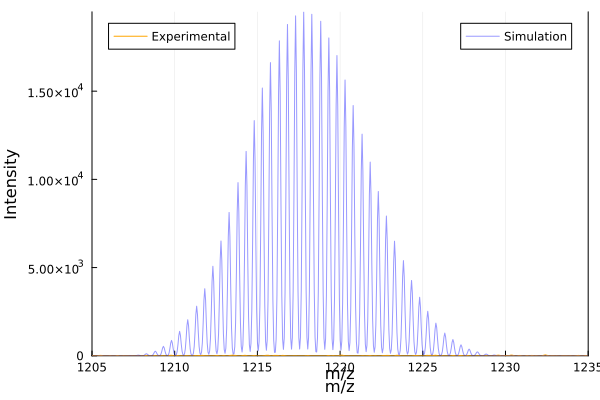

In [8]:
plot(
    a,
    method=:absolute, 
    label = "Experimental", legend =:topleft,
    xlims = (1205,1235), ylims = (0,1.95e04), 
    color = :orange,
    ylabel = "Intensity"
)
plot!(twinx(), 
    sim,
    method=:absolute, 
    label = "Simulation", 
    xlims = (1205,1235), ylims = (0.,100.),
    color = :blue,
    linealpha = 0.4,
    ylabel = "",
    yaxis=nothing
)


The simulation reproduces very well the experimental data.

We may save the figure as follow:

In [9]:
savefig(expanduser("~/figure.png"))

"/home/alex/figure.png"